In [69]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

## Import Data

In [70]:
df = pd.read_csv('./student_data.csv')
df.head()

,Student ID,Student Name,Date of Birth,Field of Study,Year of Admission,Expected Year of Graduation,Current Semester,Specialization,Fees,Discount on Fees
0,165527,Bryan Rogers,2006-01-19,Computer Science,2020,2017,3,Web Development,155152,19572
1,635763,James Hogan,1999-05-23,Mechanical Engineering,2020,2020,2,Machine Learning,157870,14760
2,740021,David Robinson,1997-12-02,Civil Engineering,2017,2022,1,Network Security,55662,5871
3,433076,Susan Miller,1999-10-30,Computer Science,2021,2019,1,Data Science,134955,17284
4,441628,Brittany Martin,1998-01-10,Chemical Engineering,2016,2018,1,Network Security,125934,14871


## Check data type

In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 10 columns):
 #   Column                       Non-Null Count   Dtype 
---  ------                       --------------   ----- 
 0   Student ID                   200000 non-null  int64 
 1   Student Name                 200000 non-null  object
 2   Date of Birth                200000 non-null  object
 3   Field of Study               200000 non-null  object
 4   Year of Admission            200000 non-null  int64 
 5   Expected Year of Graduation  200000 non-null  int64 
 6   Current Semester             200000 non-null  int64 
 7   Specialization               200000 non-null  object
 8   Fees                         200000 non-null  int64 
 9   Discount on Fees             200000 non-null  int64 
dtypes: int64(6), object(4)
memory usage: 15.3+ MB


## Check Missing Value

In [72]:
df.isnull().sum()

Student ID                     0
Student Name                   0
Date of Birth                  0
Field of Study                 0
Year of Admission              0
Expected Year of Graduation    0
Current Semester               0
Specialization                 0
Fees                           0
Discount on Fees               0
dtype: int64

In [73]:
import seaborn as sns


## Encode and drop useless variables

In [74]:
new_df = df.drop(['Student Name', 'Date of Birth', 'Student ID'], axis=1)
new_df

,Field of Study,Year of Admission,Expected Year of Graduation,Current Semester,Specialization,Fees,Discount on Fees
0,Computer Science,2020,2017,3,Web Development,155152,19572
1,Mechanical Engineering,2020,2020,2,Machine Learning,157870,14760
2,Civil Engineering,2017,2022,1,Network Security,55662,5871
3,Computer Science,2021,2019,1,Data Science,134955,17284
4,Chemical Engineering,2016,2018,1,Network Security,125934,14871
...,...,...,...,...,...,...,...
199995,Electrical Engineering,2017,2021,4,Data Science,164149,4246
199996,Electrical Engineering,2017,2019,3,Web Development,135184,12729
199997,Chemical Engineering,2022,2023,1,Data Science,139430,18237
199998,Civil Engineering,2017,2018,1,Data Science,73117,6946


In [75]:
from sklearn.preprocessing import LabelEncoder
# instantiate labelencoder object
le = LabelEncoder()

# apply le on categorical feature columns
new_df['Specialization'] = le.fit_transform(new_df['Specialization'])
new_df['Field of Study'] = le.fit_transform(new_df['Field of Study'])

<Axes: >

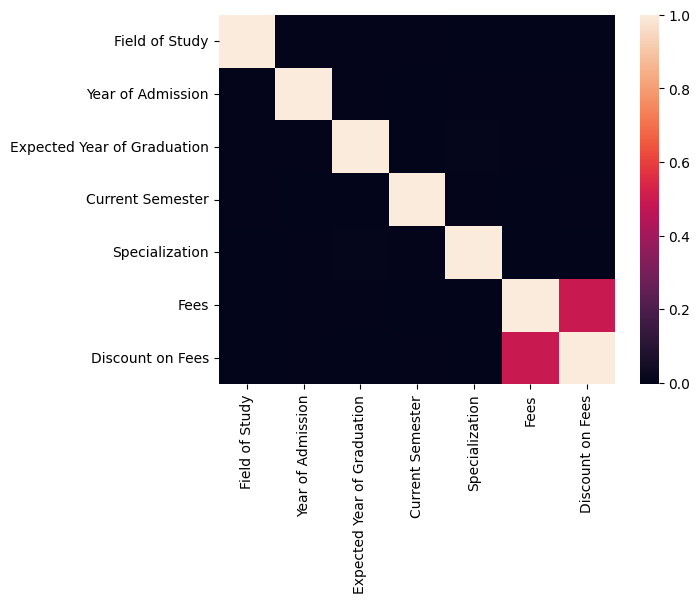

In [76]:
sns.heatmap(new_df.corr())

In [77]:
new_df = new_df.reindex(['Fees', 'Discount on Fees'], axis=1)

## Split Data

In [78]:
X = new_df.drop('Discount on Fees', axis=1)
y = new_df['Discount on Fees']

In [79]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [80]:
from sklearn.ensemble import StackingRegressor
from sklearn.ensemble import RandomForestRegressor

estimators = [
    ('ln', LinearRegression()),
    ('knn', KNeighborsRegressor()),
    ('dt', DecisionTreeRegressor()),
    ('rf', RandomForestRegressor(n_estimators=10, random_state=1))
]

stacking_regr = StackingRegressor(estimators=estimators, final_estimator=LinearRegression())
stacking_regr.fit(X_train, y_train)

StackingRegressor(estimators=[('ln', LinearRegression()),
                              ('knn', KNeighborsRegressor()),
                              ('dt', DecisionTreeRegressor()),
                              ('rf',
                               RandomForestRegressor(n_estimators=10,
                                                     random_state=1))],
                  final_estimator=LinearRegression())

In [81]:
predict_ln = stacking_regr.predict(X_test)
print("r2 :", r2_score(y_test, predict_ln))
print("MSE :", mean_squared_error(y_test, predict_ln))
print('RMSE :', mean_squared_error(y_test, predict_ln, squared=False))

r2 : 0.24187717744017878
MSE : 58997200.09062954
RMSE : 7680.963487130344
